In [7]:
import torch
import time
import datetime
import os
import argparse
import pickle 
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import random
import sys
sys.path.append(os.path.abspath('..'))
from models import *

import matplotlib.pyplot as plt
import ast
import matplotlib.tri as tri
import matplotlib.cm as cm
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [8]:
PATH="train/P1_CNN2D_test_precond"
num_gpu='1'

In [9]:
gpu_id=str(num_gpu)
os.environ['CUDA_VISIBLE_DEVICES'] = gpu_id

use_cuda = torch.cuda.is_available()
print("Is available to use cuda? : ",use_cuda)
if use_cuda:
    print("-> GPU number ",gpu_id)

Is available to use cuda? :  False


In [ ]:
gparams = {}
with open(os.path.join(PATH, "parameters.txt"), "r") as f:
    for line in f:
        key, value = line.strip().split(":")  
        if value.isdigit():  
            gparams[key] = int(value)
        else:
            try:
                gparams[key] = ast.literal_eval(value)
            except (ValueError, SyntaxError):
                gparams[key] = value

print(gparams)

In [ ]:
NAME=gparams['name']
TYPE = gparams['type']
NUM_TRAIN_DATA = gparams['num_train_data']
NUM_VALIDATE_DATA = gparams['num_validate_data']
BASIS_ORDER = gparams['basis_order']
NUM_ELEMENT = gparams['ne']

mesh=np.load(f'mesh/P{BASIS_ORDER}_ne{NUM_ELEMENT}_{TYPE}.npz')
_, NUM_PTS, p, c = mesh['ne'], mesh['ng'], mesh['p'], mesh['c']
NUM_BASIS = NUM_PTS

In [ ]:
fig=plt.figure(figsize=(5,5))
plt.title("Domain triangulation", fontsize=30)
plt.scatter(p[:,0],p[:,1], s=5)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.xlabel(r'$x$', fontsize=20)
plt.ylabel(r'$y$', fontsize=20)
for i in range(len(c)):
    plt.plot(p[c[i][0:3]][:,0],p[c[i][0:3]][:,1],c='b', linewidth=0.3)
    plt.plot(np.array([p[c[i][2]],p[c[i][0]]])[:,0],np.array([p[c[i][2]],p[c[i][0]]])[:,1],c='b', linewidth=0.3)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# === Use Times New Roman-style without LaTeX ===
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['text.usetex'] = False  # Disable LaTeX
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['axes.linewidth'] = 1.2

# === Your Plot Code ===
fig = plt.figure(figsize=(5, 5))
#plt.title("Domain Triangulation", fontsize=20)
plt.scatter(p[:, 0], p[:, 1], s=5, color='black')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)

for i in range(len(c)):
    tri_pts = p[c[i][:3]]
    plt.plot(tri_pts[:, 0], tri_pts[:, 1], color='blue', linewidth=0.4)
    plt.plot([tri_pts[2, 0], tri_pts[0, 0]], [tri_pts[2, 1], tri_pts[0, 1]], color='blue', linewidth=0.4)

plt.gca().set_aspect('equal')
plt.tight_layout()
plt.savefig("domain_square.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [7]:
models = {
          'CNN1D': CNN1D,
          'CNN2D': CNN2D,
          }
MODEL = models[gparams['model']]
BLOCKS = int(gparams['blocks'])
KERNEL_SIZE = int(gparams['ks'])
FILTERS = int(gparams['filters'])
PADDING = (KERNEL_SIZE - 1)//2
ACT = gparams['act']
if gparams['model']=='CNN2D':
    RESOL_IN=gparams['resol_in']
D_in = 1
D_out = NUM_BASIS

In [ ]:
class Dataset(Dataset):
    def __init__(self, mesh, kind='train', num_train=False):
        self.kind=kind
        self.num_train=num_train
        pickle_file_load = f'{self.kind}_P{BASIS_ORDER}_{NUM_TRAIN_DATA}N{NUM_ELEMENT}_{TYPE}'
        with open(f'data/{pickle_file_load}.pkl', 'rb') as f:
            self.data = pickle.load(f)
        self.load_vector = mesh[f'{kind}_load_vectors']
    def __getitem__(self, idx):
        coeff_u = torch.FloatTensor(self.data[idx,0]).unsqueeze(0)
        f_value = torch.FloatTensor(self.data[idx,1]).unsqueeze(0)
        coeff_f = torch.FloatTensor(self.data[idx,2])
        load_vec_f = torch.FloatTensor(self.load_vector[idx])
        return {'coeff_u': coeff_u, 'f_value': f_value, 'coeff_f': coeff_f, 'load_vec_f' : load_vec_f}

    def __len__(self):
        if self.kind=='train':
            return self.num_train
        else:
            return len(self.data)

lg_dataset = Dataset(mesh, kind='train', num_train=NUM_TRAIN_DATA)
trainloader = DataLoader(lg_dataset, batch_size=NUM_TRAIN_DATA, shuffle=False)
lg_dataset = Dataset(mesh, kind='validate')
validateloader = DataLoader(lg_dataset, batch_size=NUM_VALIDATE_DATA, shuffle=False)

print("Num train : {}, Num test: {}".format(len(trainloader.dataset), len(validateloader.dataset)))

In [9]:
if gparams['model']=='CNN2D':
    model = MODEL(ACT, RESOL_IN, D_in, FILTERS, D_out, kernel_size=KERNEL_SIZE, padding=PADDING, blocks=BLOCKS)
else:
    model = MODEL(ACT, D_in, FILTERS, D_out, kernel_size=KERNEL_SIZE, padding=PADDING, blocks=BLOCKS)

model.cuda()
load_model = torch.load(os.path.join(PATH, "model.pt"))
model.load_state_dict(load_model['model_state_dict'])

/tmp/ipykernel_109657/3380104155.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_model = torch.load(os.path.join(PATH, "model.pt"))


<All keys matched successfully>

In [10]:
for validate_data in validateloader:
    coeff_u = validate_data['coeff_u']
    coeff_f = validate_data['coeff_f']
    data_f = validate_data['f_value']

In [11]:
PATH_precond="train/P1_CNN2D_test_precond"

if gparams['model']=='CNN2D':
    model_precond = MODEL(ACT, RESOL_IN, D_in, FILTERS, D_out, kernel_size=KERNEL_SIZE, padding=PADDING, blocks=BLOCKS)
else:
    model_precond = MODEL(ACT, D_in, FILTERS, D_out, kernel_size=KERNEL_SIZE, padding=PADDING, blocks=BLOCKS)


PRECOND=mesh['precond']
PRECOND = torch.tensor(PRECOND).cuda().float()
model_precond.cuda()
load_model = torch.load(os.path.join(PATH_precond, "model.pt"))
model_precond.load_state_dict(load_model['model_state_dict'])

/tmp/ipykernel_109657/372551357.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_model = torch.load(os.path.join(PATH_precond, "model.pt"))


<All keys matched successfully>

In [12]:
def f(x,y,coeff):
    m0, m1, n0, n1, n2, n3=coeff[:,[0]], coeff[:,[1]], coeff[:,[2]], coeff[:,[3]], coeff[:,[4]], coeff[:,[5]]
    return m0*torch.sin(n0*x+n1*y) + m1*torch.cos(n2*x+n3*y)

In [13]:
grid_x=torch.linspace(-1,1,RESOL_IN)
input_grid=torch.cartesian_prod(grid_x,grid_x).cuda()

In [14]:
def rel_L2_error(pred, true):
    return (torch.sum((true-pred)**2, axis=-1)/torch.sum((true)**2, axis=-1))**0.5

Plot index: 11


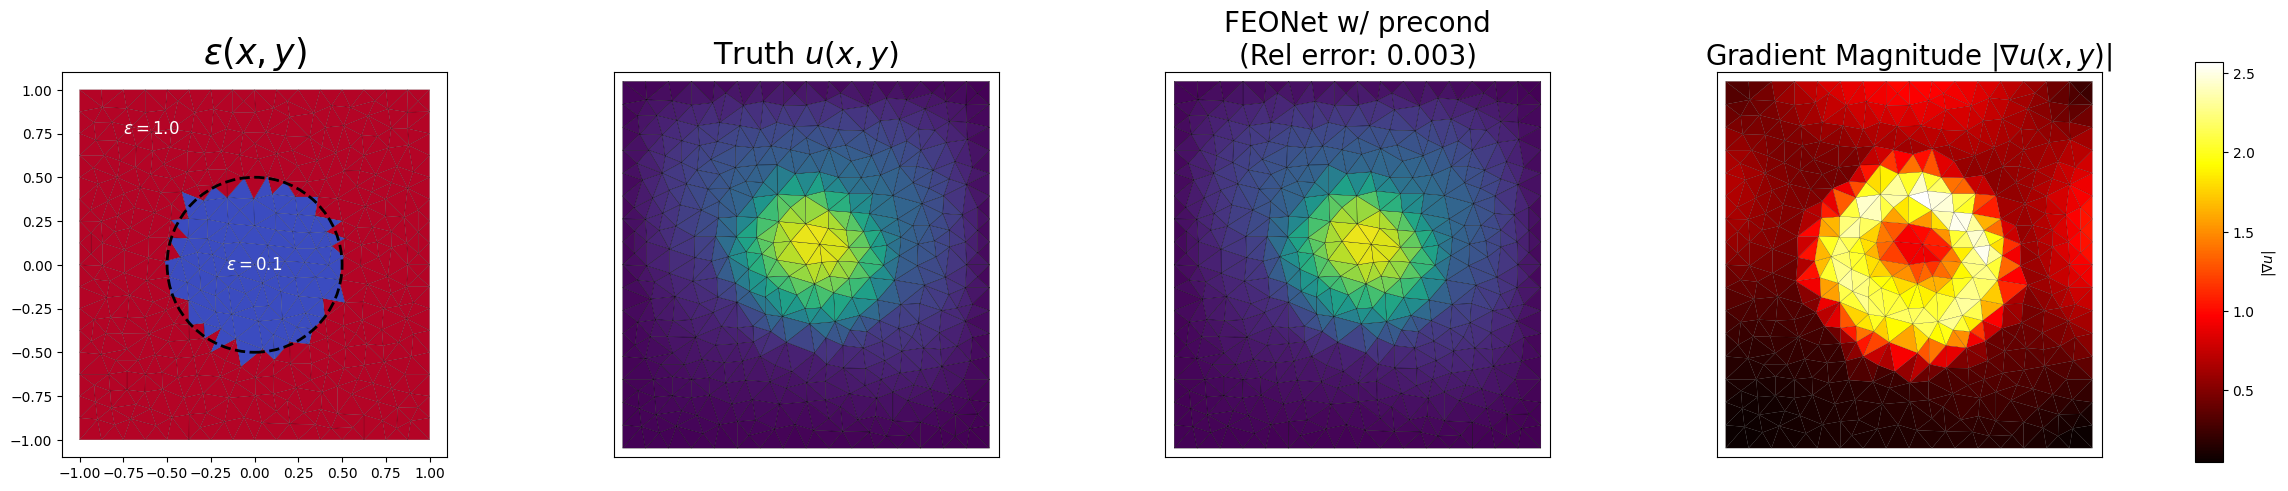

In [20]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

plot_idx = 11
print(f"Plot index: {plot_idx}")

x = p[:, 0]
y = p[:, 1]

_data_f = data_f[[plot_idx]].cuda()
_coeff_f = coeff_f[[plot_idx]].cuda()
_coeff_u = coeff_u[[plot_idx]].cuda()

value_f = f(input_grid[:, 0], input_grid[:, 1], _coeff_f).reshape(-1, 1, RESOL_IN, RESOL_IN)

output_u_original = model(value_f)
output_u_precondition = model_precond(value_f)
output_u_precondition = (PRECOND @ output_u_precondition.transpose(1, 2)).transpose(1, 2)

mini, maxi = min(_coeff_u[0][0]), max(_coeff_u[0][0])

triang = tri.Triangulation(x, y)

# Define epsilon with discontinuity
eps = np.where(np.sqrt(x**2 + y**2) < 0.5, 0.1, 1.0)

# ----------------------
# Compute gradient magnitude
# ----------------------
from scipy.spatial import Delaunay

u_vals = _coeff_u[0][0].cpu().numpy()
triang_data = triang.triangles

# Initialize gradient magnitude
grad_mag = np.zeros(len(x))

# Compute gradients per triangle
for tri_idx in triang_data:
    x_tri = x[tri_idx]
    y_tri = y[tri_idx]
    u_tri = u_vals[tri_idx]

    # Compute area of triangle
    mat = np.array([
        [x_tri[1] - x_tri[0], x_tri[2] - x_tri[0]],
        [y_tri[1] - y_tri[0], y_tri[2] - y_tri[0]],
    ])
    area = 0.5 * np.abs(np.linalg.det(mat))

    # Build matrix for linear function gradient
    A = np.array([
        [x_tri[0], y_tri[0], 1],
        [x_tri[1], y_tri[1], 1],
        [x_tri[2], y_tri[2], 1]
    ])
    coeffs = np.linalg.solve(A, u_tri)
    du_dx, du_dy = coeffs[0], coeffs[1]

    # Assign |∇u| to each vertex of the triangle
    mag = np.sqrt(du_dx**2 + du_dy**2)
    for idx in tri_idx:
        grad_mag[idx] += mag

# Normalize by number of triangle contributions per point
counts = np.bincount(triang_data.flatten(), minlength=len(x))
grad_mag /= (counts + 1e-10)  # Avoid divide by zero

# ----------------------
# Begin Plotting
# ----------------------
fig = plt.figure(figsize=(28, 5), dpi=100)

# Panel 1: ε(x, y)
ax = plt.subplot(1, 4, 1)
ax.set_title(r'$\varepsilon(x,y)$', fontsize=25)
#eps_elem = eps  # Replace if you compute element-wise ε
eps_elem = np.mean(eps[triang.triangles], axis=1)  # Add this before plotting
im = ax.tripcolor(triang, facecolors=eps_elem, shading='flat',
                  cmap=ListedColormap(['#3B4CC0', '#B40426']),
                  norm=BoundaryNorm([0.05, 0.55, 1.05], 2),
                  edgecolors='k', linewidth=0.1)
circle = plt.Circle((0, 0), 0.5, color='black', fill=False, linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.text(0, 0, r'$\varepsilon=0.1$', ha='center', va='center', fontsize=12, color='white')
ax.text(-0.75, 0.75, r'$\varepsilon=1.0$', fontsize=12, color='white')
ax.set_aspect(1)

# Panel 2: Ground truth u(x, y)
ax = plt.subplot(1, 4, 2)
ax.set_title(r'Truth $u(x,y)$', fontsize=22)
im = ax.tripcolor(triang, u_vals, shading='flat', cmap='viridis',
                  vmin=mini, vmax=maxi, edgecolors='k', linewidth=0.2)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

# Panel 3: FEONet output
ax = plt.subplot(1, 4, 3)
error_precondition = rel_L2_error(output_u_precondition[0][0].detach().cpu(), _coeff_u[0][0].cpu())
ax.set_title(f'FEONet w/ precond\n(Rel error: {error_precondition:.3f})', fontsize=20)
im = ax.tripcolor(triang, output_u_precondition[0][0].detach().cpu(), shading='flat',
                  cmap='viridis', vmin=mini, vmax=maxi,
                  edgecolors='k', linewidth=0.2)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

# Panel 4: Gradient Magnitude |∇u|
ax = plt.subplot(1, 4, 4)
ax.set_title(r'Gradient Magnitude $|\nabla u(x,y)|$', fontsize=20)
im = ax.tripcolor(triang, grad_mag, shading='flat', cmap='hot',
                  edgecolors='k', linewidth=0.1)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

# Colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.10, 0.01, 0.8])
fig.colorbar(im, cax=cbar_ax, label=r'$|\nabla u|$')

# Save if needed
# plt.savefig("figures/feonet_discontinuity_panel.pdf", bbox_inches="tight")
plt.show()



Is available to use cuda? :  False

Running on dataset root: 5_times_data


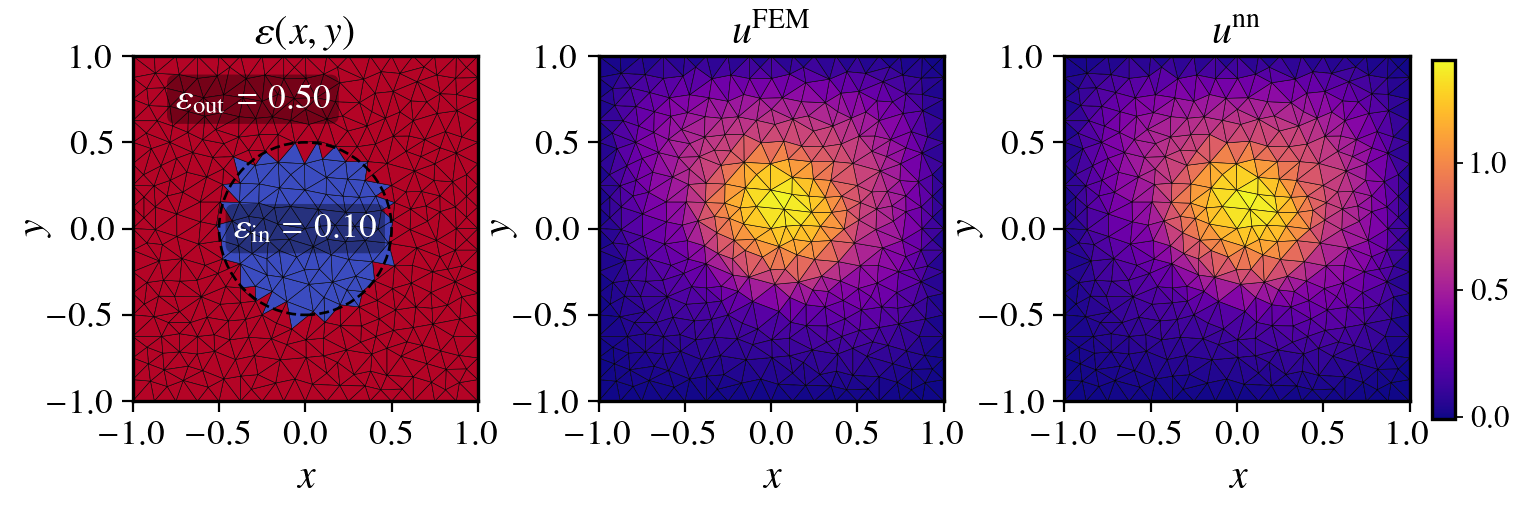


Running on dataset root: 10_times_data


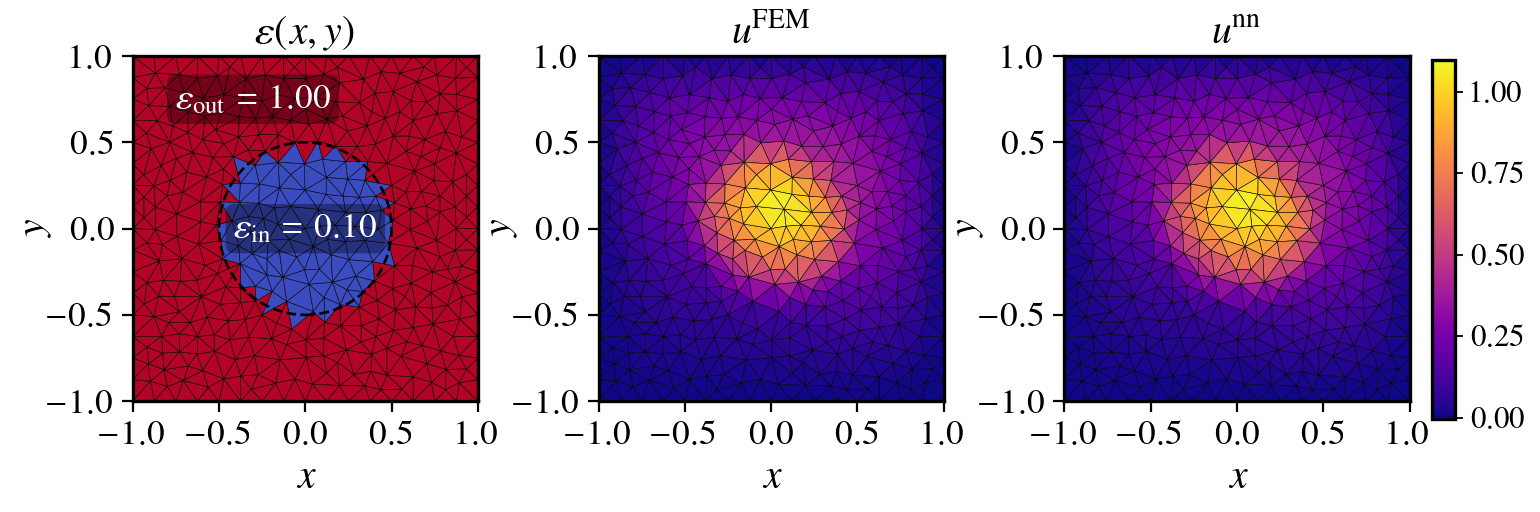


Running on dataset root: 20_times_data


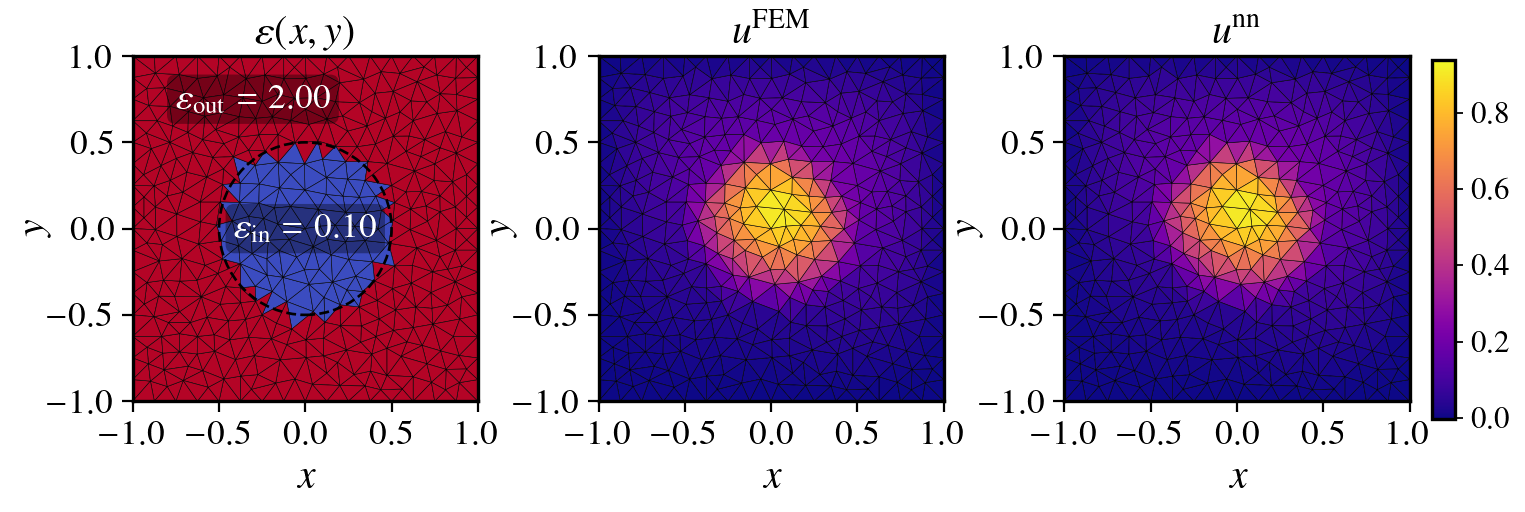

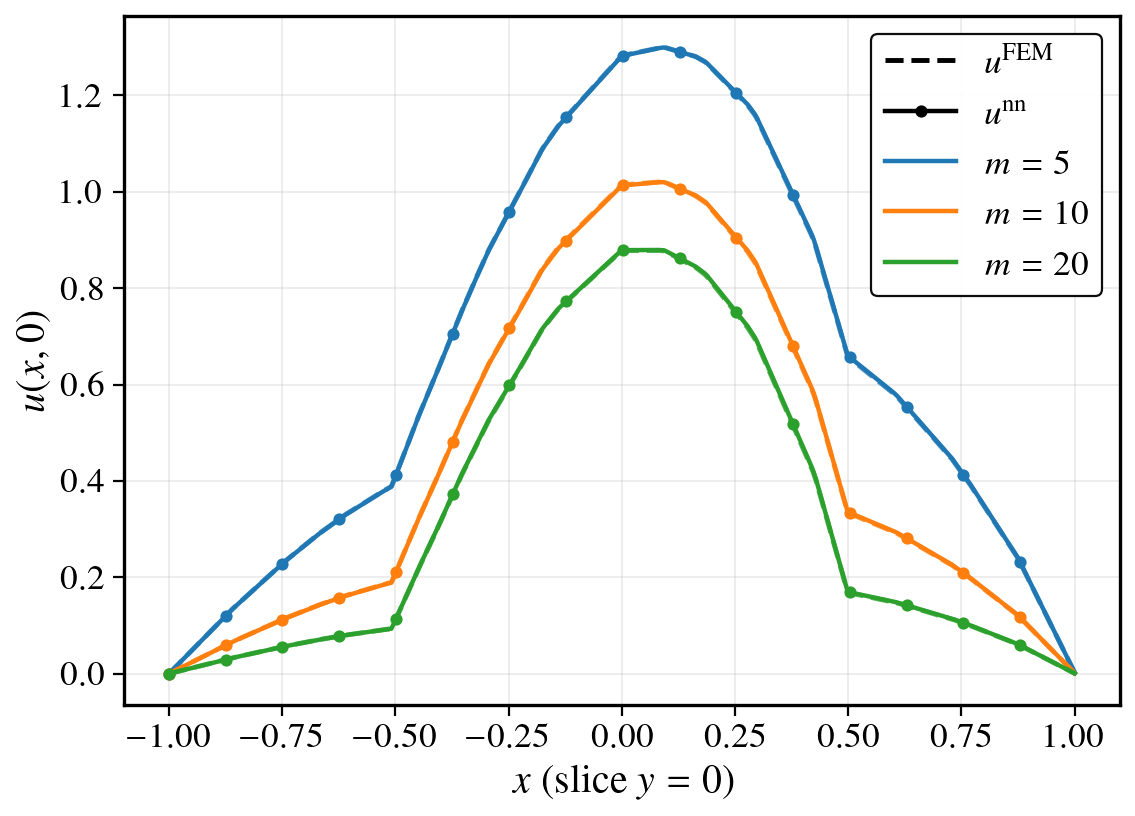

In [22]:
# ============================================================
# UPDATED: NumPy2->NumPy1 pickle compatibility + CPU-safe plotting script
# ============================================================

import os
import sys
import ast
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from torch.utils.data import Dataset, DataLoader
import matplotlib.lines as mlines

# ------------------------------------------------------------
# Paper-style plotting (same style as before)
# ------------------------------------------------------------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"""
        \usepackage{amsmath,amssymb,amsfonts}
        \usepackage{txfonts}
    """,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 2,
    "lines.markersize": 8,
    "axes.linewidth": 1.5,
})

# ------------------------------------------------------------
# NumPy 2.x -> NumPy 1.x pickle loader (fixes numpy._core.numeric)
# ------------------------------------------------------------
def pickle_load_numpy_compat(file_obj):
    class NumpyCompatUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    return NumpyCompatUnpickler(file_obj).load()

# ------------------------------------------------------------
# import your models
# ------------------------------------------------------------
sys.path.append(os.path.abspath(".."))
from models import *

ROOT_DIRS = ["5_times_data", "10_times_data", "20_times_data"]

# ------------------------------------------------------------
# Device (CPU on MacBook, CUDA if available)
# ------------------------------------------------------------
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print("Is available to use cuda? : ", use_cuda)

def read_params_from(root_dir):
    param_dir = os.path.join(root_dir, "train", "P1_CNN2D_test_precond")
    param_file = os.path.join(param_dir, "parameters.txt")
    gparams = {}
    with open(param_file, "r") as f:
        for line in f:
            key, value = line.strip().split(":")
            if value.isdigit():
                gparams[key] = int(value)
            else:
                try:
                    gparams[key] = ast.literal_eval(value)
                except (ValueError, SyntaxError):
                    gparams[key] = value
    return gparams, param_dir

def rel_L2_error(pred, true):
    return (torch.sum((true - pred) ** 2, axis=-1) / torch.sum((true) ** 2, axis=-1)) ** 0.5

class PDEData(Dataset):
    def __init__(self, base_dir, mesh, kind, basis_order, num_train_data, num_element, dtype, num_train=None):
        self.base_dir = base_dir
        self.kind = kind
        self.num_train = num_train
        fname = f"{kind}_P{basis_order}_{num_train_data}N{num_element}_{dtype}.pkl"
        pkl_path = os.path.join(base_dir, "data", fname)
        with open(pkl_path, "rb") as f:
            # <<< CRITICAL FIX
            self.data = pickle_load_numpy_compat(f)
        self.load_vector = mesh[f"{kind}_load_vectors"]

    def __getitem__(self, idx):
        coeff_u = torch.tensor(self.data[idx, 0], dtype=torch.float32).unsqueeze(0)
        f_value = torch.tensor(self.data[idx, 1], dtype=torch.float32).unsqueeze(0)
        coeff_f = torch.tensor(self.data[idx, 2], dtype=torch.float32)
        load_vec_f = torch.tensor(self.load_vector[idx], dtype=torch.float32)
        return {"coeff_u": coeff_u, "f_value": f_value, "coeff_f": coeff_f, "load_vec_f": load_vec_f}

    def __len__(self):
        if self.kind == "train" and self.num_train is not None:
            return self.num_train
        return len(self.data)

def forcing_fun(x, y, coeff):
    m0, m1, n0, n1, n2, n3 = (coeff[:, [0]], coeff[:, [1]], coeff[:, [2]],
                             coeff[:, [3]], coeff[:, [4]], coeff[:, [5]])
    return m0 * torch.sin(n0 * x + n1 * y) + m1 * torch.cos(n2 * x + n3 * y)

def dataset_eps_range(root_name):
    if root_name.startswith("5_"):
        return 0.10, 0.50
    if root_name.startswith("10_"):
        return 0.10, 1.00
    if root_name.startswith("20_"):
        return 0.10, 2.00
    return 0.19, 1.69

def format_square_axis(ax):
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.tick_params(direction="out", length=5, width=1)
    for sp in ["top", "right", "bottom", "left"]:
        ax.spines[sp].set_visible(True)

# keep slices for final line plot
all_slices = {}
color_map = {"5_times_data": "tab:blue", "10_times_data": "tab:orange", "20_times_data": "tab:green"}

# ============================================================
# per-folder loop
# ============================================================
for ROOT in ROOT_DIRS:
    print("\n========================")
    print(f"Running on dataset root: {ROOT}")
    print("========================")

    gparams, _ = read_params_from(ROOT)
    TYPE = gparams["type"]
    NUM_TRAIN_DATA = gparams["num_train_data"]
    NUM_VALIDATE_DATA = gparams["num_validate_data"]
    BASIS_ORDER = gparams["basis_order"]
    NUM_ELEMENT = gparams["ne"]
    MODEL_NAME = gparams["model"]
    BLOCKS = int(gparams["blocks"])
    KERNEL_SIZE = int(gparams["ks"])
    FILTERS = int(gparams["filters"])
    ACT = gparams["act"]
    RESOL_IN = gparams["resol_in"] if MODEL_NAME == "CNN2D" else None
    D_in = 1

    mesh_path = os.path.join(ROOT, "mesh", f"P{BASIS_ORDER}_ne{NUM_ELEMENT}_{TYPE}.npz")
    mesh = np.load(mesh_path)
    p, c = mesh["p"], mesh["c"]
    NUM_BASIS = p.shape[0]

    valid_dataset = PDEData(ROOT, mesh, "validate", BASIS_ORDER, NUM_TRAIN_DATA, NUM_ELEMENT, TYPE)
    validloader = DataLoader(valid_dataset, batch_size=NUM_VALIDATE_DATA, shuffle=False)

    models_dict = {"CNN1D": CNN1D, "CNN2D": CNN2D}
    MODEL_CLS = models_dict[MODEL_NAME]

    if MODEL_NAME == "CNN2D":
        model_precond = MODEL_CLS(ACT, RESOL_IN, D_in, FILTERS, NUM_BASIS,
                                  kernel_size=KERNEL_SIZE, padding=(KERNEL_SIZE - 1)//2, blocks=BLOCKS)
    else:
        model_precond = MODEL_CLS(ACT, D_in, FILTERS, NUM_BASIS,
                                  kernel_size=KERNEL_SIZE, padding=(KERNEL_SIZE - 1)//2, blocks=BLOCKS)

    model_precond.to(device).eval()

    ckpt_path = os.path.join(ROOT, "train", "P1_CNN2D_test_precond", "model.pt")
    state = torch.load(ckpt_path, map_location=device)
    sd = state["model_state_dict"] if isinstance(state, dict) and "model_state_dict" in state else state
    model_precond.load_state_dict(sd)

    PRECOND = torch.tensor(mesh["precond"], dtype=torch.float32, device=device)

    for validate_data in validloader:
        coeff_u = validate_data["coeff_u"]
        coeff_f = validate_data["coeff_f"]
        break

    grid_x = torch.linspace(-1, 1, RESOL_IN, device=device)
    input_grid = torch.cartesian_prod(grid_x, grid_x)

    plot_idx = min(11, len(valid_dataset) - 1)
    _coeff_u = coeff_u[[plot_idx]].to(device)
    _coeff_f = coeff_f[[plot_idx]].to(device)

    value_f = forcing_fun(input_grid[:, 0], input_grid[:, 1], _coeff_f).reshape(-1, 1, RESOL_IN, RESOL_IN)

    with torch.no_grad():
        out_pre = model_precond(value_f)
        out_pre = (PRECOND @ out_pre.transpose(1, 2)).transpose(1, 2)

    truth_vals = _coeff_u[0][0].detach().cpu().numpy()
    pred_vals  = out_pre[0][0].detach().cpu().numpy()

    vmin, vmax = float(truth_vals.min()), float(truth_vals.max())

    # slice storage
    triang_nodes = tri.Triangulation(p[:, 0], p[:, 1])
    interp_truth = tri.LinearTriInterpolator(triang_nodes, truth_vals)
    interp_pred  = tri.LinearTriInterpolator(triang_nodes, pred_vals)
    x_line = np.linspace(-1.0, 1.0, 400)
    y_line = np.zeros_like(x_line)
    all_slices[ROOT] = {"x": x_line,
                        "truth": np.array(interp_truth(x_line, y_line)),
                        "pred":  np.array(interp_pred(x_line, y_line))}

    # elementwise triangulation
    x = p[:, 0]; y = p[:, 1]
    cells = c
    if cells.shape[0] == 3 and cells.shape[1] != 3:
        cells = cells.T
    triang = tri.Triangulation(x, y, triangles=cells)

    eps_in, eps_out = dataset_eps_range(ROOT)
    r0 = 0.5
    r = np.sqrt(x**2 + y**2)
    eps_nodes = np.where(r < r0, eps_in, eps_out)
    eps_elem = eps_nodes[cells].mean(axis=1)

    truth_elem = truth_vals[cells].mean(axis=1)
    pred_elem  = pred_vals[cells].mean(axis=1)

    err_rel = rel_L2_error(
        torch.from_numpy(pred_vals).unsqueeze(0),
        torch.from_numpy(truth_vals).unsqueeze(0),
    ).item()

    # ---------------- 3 panels ----------------
    fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.3), dpi=160)

    # 1) eps
    ax1 = axes[0]
    ax1.set_title(r"$\varepsilon(x,y)$")
    cmap_eps = ListedColormap(["#3B4CC0", "#B40426"])
    bounds = [eps_in - 1e-6, (eps_in + eps_out) / 2.0, eps_out + 1e-6]
    norm_eps = BoundaryNorm(bounds, cmap_eps.N)

    ax1.tripcolor(triang, facecolors=eps_elem, shading="flat",
                  cmap=cmap_eps, norm=norm_eps, edgecolors="k", linewidth=0.25)

    circle = plt.Circle((0, 0), r0, color="black", fill=False, linewidth=1.2, linestyle="--")
    ax1.add_patch(circle)

    # eps_in inside circle
    ax1.text(0.0, 0.0, rf"$\varepsilon_{{\rm in}}={eps_in:.2f}$",
             ha="center", va="center", fontsize=16, color="white",
             bbox=dict(facecolor="black", alpha=0.35, edgecolor="none",
                       boxstyle="round,pad=0.25"))

    # eps_out outside circle
    ax1.text(-0.75, 0.75, rf"$\varepsilon_{{\rm out}}={eps_out:.2f}$",
             ha="left", va="center", fontsize=16, color="white",
             bbox=dict(facecolor="black", alpha=0.35, edgecolor="none",
                       boxstyle="round,pad=0.25"))

    format_square_axis(ax1)

    # 2) FEM
    ax2 = axes[1]
    ax2.set_title(r"$u^{\mathrm{FEM}}$")
    im2 = ax2.tripcolor(triang, facecolors=truth_elem, shading="flat",
                        cmap="plasma", vmin=vmin, vmax=vmax,
                        edgecolors="k", linewidth=0.25)
    format_square_axis(ax2)

    # 3) NN
    ax3 = axes[2]
    ax3.set_title(r"$u^{\mathrm{nn}}$")
    im3 = ax3.tripcolor(triang, facecolors=pred_elem, shading="flat",
                        cmap="plasma", vmin=vmin, vmax=vmax,
                        edgecolors="k", linewidth=0.25)
    format_square_axis(ax3)
    for ax in axes:
        ax.set_ylabel(r"$y$", labelpad=-2)   # or use set_label_coords(...)


    # thin colorbar
    cax = fig.add_axes([0.915, 0.16, 0.015, 0.68])
    cbar = fig.colorbar(im3, cax=cax)
    #cbar.set_label(r"$u(x,y)$", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    fig.subplots_adjust(left=0.06, right=0.9, top=0.88, bottom=0.16, wspace=0.35)
    plt.savefig(f"{ROOT}_2d_sol.png", bbox_inches="tight", dpi=300)
    plt.show()

# ============================================================
# final 1D slice plot (paper-style; solid markers)
# ============================================================
fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=160)
ax.set_xlabel(r"$x$ (slice $y=0$)")
ax.set_ylabel(r"$u(x,0)$")
ax.grid(True, alpha=0.25)
ax.tick_params(direction="out", length=5, width=1)
for sp in ["top", "right", "bottom", "left"]:
    ax.spines[sp].set_visible(True)

marker_every = 25
marker_size = 5.5

for ROOT, sl in all_slices.items():
    x = sl["x"]; truth = sl["truth"]; pred = sl["pred"]
    col = color_map.get(ROOT, "k")
    ax.plot(x, truth, "--", linewidth=2.2, color=col, alpha=0.75)
    ax.plot(x, pred, "-", linewidth=2.0, color=col,
            marker="o", markersize=marker_size, markevery=marker_every,
            markerfacecolor=col, markeredgecolor=col, markeredgewidth=0.0)

h_truth = mlines.Line2D([], [], color="black", linestyle="--", linewidth=2.2, label=r"$u^{\mathrm{FEM}}$")
h_pred  = mlines.Line2D([], [], color="black", linestyle="-", linewidth=2.0,
                        marker="o", markersize=marker_size,
                        markerfacecolor="black", markeredgewidth=0.0,
                        label=r"$u^{\mathrm{nn}}$")

h_5  = mlines.Line2D([], [], color="tab:blue",   linestyle="-", linewidth=2.0, label=r"$m=5$")
h_10 = mlines.Line2D([], [], color="tab:orange", linestyle="-", linewidth=2.0, label=r"$m=10$")
h_20 = mlines.Line2D([], [], color="tab:green",  linestyle="-", linewidth=2.0, label=r"$m=20$")

ax.legend(handles=[h_truth, h_pred, h_5, h_10, h_20],
          loc="upper right", frameon=True, framealpha=0.95, edgecolor="black")

plt.tight_layout()
plt.show()
